In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

class DroneDeliveryEnvironment(gym.Env):
    def __init__(self, stochastic=False):
        self.grid_size = 6
        self.action_space = gym.spaces.Discrete(6)
        self.observation_space = gym.spaces.MultiDiscrete([self.grid_size, self.grid_size, 2])
        
        self.warehouse_pos = np.array([3, 1])
        self.customer_pos = np.array([4, 4])
        self.no_fly_zones = [np.array([2, 2]), np.array([3, 3]), np.array([1, 4])]
        self.start_pos = np.array([0, 0])
        self.stochastic = stochastic
        self.reset()
    
    def reset(self, start_pos=None, target_pos=None):
        self.drone_pos = start_pos if start_pos is not None else self.start_pos.copy()
        self.target_pos = target_pos if target_pos is not None else self.customer_pos.copy()
        self.package_picked = False
        return self._get_observation()
    
    def step(self, action):
        reward = -1
        terminated = False
        new_pos = self.drone_pos.copy()
 
        if action == 0:
            new_pos[1] += 1 if self.drone_pos[1] < self.grid_size - 1 else 0
        elif action == 1:
            new_pos[1] -= 1 if self.drone_pos[1] > 0 else 0
        elif action == 2:
            new_pos[0] -= 1 if self.drone_pos[0] > 0 else 0
        elif action == 3:
            new_pos[0] += 1 if self.drone_pos[0] < self.grid_size - 1 else 0
        elif action == 4 and np.array_equal(self.drone_pos, self.warehouse_pos):
            self.package_picked = True
            reward = 25
        elif action == 5 and np.array_equal(self.drone_pos, self.target_pos) and self.package_picked:
            self.package_picked = False
            reward = 100
            terminated = True
        
        if self.stochastic:
            if np.random.rand() < 0.1:  # with 10% probability, wind effect occurs
                deviation = np.random.choice([-1, 1], size=2)
                print(f"Wind effect! Drone deviates to {new_pos + deviation}")
                new_pos += deviation
                
            if np.random.rand() < 0.5:
                if np.random.rand() < 0.5 and len(self.no_fly_zones) > 0:
                    removed_zone = self.no_fly_zones.pop(np.random.randint(len(self.no_fly_zones)))
                    print(f"No-fly zone removed at {removed_zone}")
                else:
                    new_zone = np.random.randint(0, self.grid_size, size=2)
                    if not np.array_equal(new_zone, self.warehouse_pos) and not np.array_equal(new_zone, self.target_pos):
                        self.no_fly_zones.append(new_zone)
                        self.no_fly_zones = [np.array(zone) for zone in set(tuple(zone) for zone in self.no_fly_zones)]
                        print(f"New no-fly zone added at {new_zone}")
            
            if np.random.rand() < 0.05:
                self.target_pos = np.random.randint(0, self.grid_size, size=2)
                print(f"New target assigned: {self.target_pos}")
        
        if any(np.array_equal(new_pos, zone) for zone in self.no_fly_zones):
            reward = -100
            self.drone_pos = self.warehouse_pos.copy()
            print("No-fly zone encountered! Returning to start.")
        else:
            self.drone_pos = np.clip(new_pos, 0, self.grid_size - 1)
        
        return self._get_observation(), reward, terminated, {}
    
    def _get_observation(self):
        return np.array([self.drone_pos[0], self.drone_pos[1], int(self.package_picked)])
    
    def render(self, mode='human'):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks(range(self.grid_size))
        ax.set_yticks(range(self.grid_size))
        ax.grid(True)
        
        def add_image(ax, img_path, pos, zoom=0.2):
            img = plt.imread(img_path)
            imagebox = OffsetImage(img, zoom=0.2)
            ab = AnnotationBbox(imagebox, np.add(pos, [0.5, 0.5]), frameon=False)
            ax.add_artist(ab)
        print(self.package_picked)
        if not self.package_picked:
            add_image(ax, './images/box.jpg', self.warehouse_pos)  # Show warehouse if package is present
        
        add_image(ax, './images/customer.jpg', self.customer_pos)
        for zone in self.no_fly_zones:
            add_image(ax, './images/noflyzone.png', zone)
        
        drone_img = './images/drone with image.jpg' if self.package_picked else './images/drone.jpg'
        add_image(ax, drone_img, self.drone_pos)
        
        plt.show()


In [9]:

# Running a random agent for 10 timesteps in stochastic mode
# env = DroneDeliveryEnvironment(stochastic=False)
# obs = env.reset()

# env.render()
# for t in range(10):
#     action = env.action_space.sample()
#     obs, reward, done, _ = env.step(action)
#     print(f"Step {t + 1}: Action = {action}, Reward = {reward}, Terminated = {done}")
#     env.render()
#     if done:
#         break

In [10]:
env = DroneDeliveryEnvironment(stochastic=False)

Action = 5, Reward = -1, Terminated = False
False


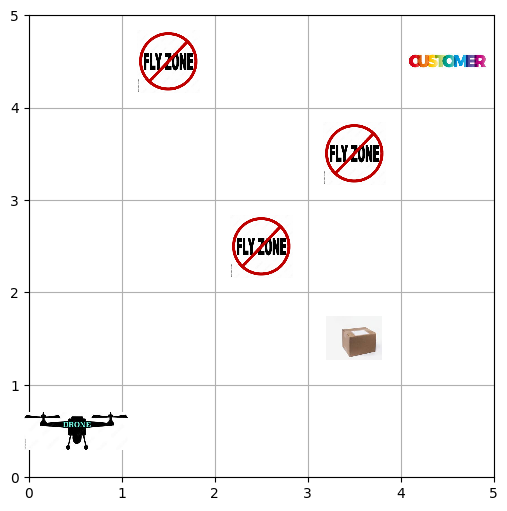

In [11]:
action = 5
obs, reward, done, _ = env.step(action)
print(f"Action = {action}, Reward = {reward}, Terminated = {done}")
env.render()